# Linear Regression Analysis — Interactive Notebook

This notebook reproduces the linear regression analysis from `Pricescraper/6_analysis/linear_regression_analysis.py` and displays all figures inline. It also writes the same outputs to `reports/figures/linear_regression_analysis/` for record keeping.


In [1]:
# Imports and module loader
import sys
from pathlib import Path
from IPython.display import display, Image, Markdown
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm

# Pretty plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Notebook is in the same folder as the module
module_path = Path('scripts/linear_regression_analysis.py')
spec = importlib.util.spec_from_file_location('scripts/linear_regression_analysis', str(module_path))
lra = importlib.util.module_from_spec(spec)
spec.loader.exec_module(lra)

# Output directory used by the script
figures_dir = Path('../../reports/figures/cluster_market_personalities')
figures_dir.mkdir(parents=True, exist_ok=True)

# Override seaborn styling from imported module with simple matplotlib style
plt.style.use('default')  # Use default matplotlib style
plt.rcParams.update(plt.rcParamsDefault)  # Reset to default matplotlib parameters




c:\Users\ugnek\OneDrive - ETH Zurich\Desktop\Doktorat\03_Student work\old\Felix Morlock\PricescraperCCDS\PricescraperCCDS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Ensure working directory is the project root so relative data paths work
needed = Path('data/processed/filtered_hplib_w_prices_and_decoding.csv')
if not needed.exists():
    # Walk up to 6 levels to find the repo root containing 'data/processed/...'
    cur = Path.cwd()
    for _ in range(6):
        candidate = cur / needed
        if candidate.exists():
            os.chdir(cur)
            break
        cur = cur.parent

df = lra.load_data()
df = lra.clean_data(df)

display(df.head())
print(f"Loaded {len(df)} rows and {df.shape[1]} columns")

# Print data overview
print(f"\nDATA OVERVIEW:")
print(f"Total manufacturers: {df['Manufacturer'].nunique()}")
if 'Configuration_Group' in df.columns:
    print(f"Total configurations: {df['Configuration_Group'].nunique()}")
    print(f"Configuration distribution:")
    config_counts = df['Configuration_Group'].value_counts()
    for config, count in config_counts.items():
        print(f"  {config}: {count} units ({count/len(df)*100:.1f}%)")
if 'Refrigerant' in df.columns:
    print(f"Total refrigerants: {df['Refrigerant'].nunique()}")
    print(f"Refrigerant distribution:")
    refrigerant_counts = df['Refrigerant'].value_counts()
    for ref, count in refrigerant_counts.items():
        print(f"  {ref}: {count} units ({count/len(df)*100:.1f}%)")


,Manufacturer,Model,Titel,Date,Model/Type,Price,Currency,Website,Date_scraped,Type,...,SCOP,SEER low T,SEER medium T,P_th_h_ref [W],P_th_c_ref [W],P_el_h_ref [W],P_el_c_ref [W],COP_ref,EER_c_ref,Configuration_Group
0,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS6800iAW 7 ORE-S,30.03.2023,Bosch Set BOPA CS772 AW 7 OR-S CS6800iAW 12 E ...,9933.0,EUR,idealo,2025-03-14,Outdoor Air/Water,...,4.58,NaN,NaN,5940.0,NaN,2842.0,NaN,2.09,NaN,monoblock - hydraulic module
1,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 4 ORM-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS761 AW 4 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,...,4.55,NaN,NaN,3510.0,NaN,1671.0,NaN,2.10,NaN,monoblock - warm-water tank
2,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 5 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS774 AW 5 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,...,4.55,NaN,NaN,5530.0,NaN,2646.0,NaN,2.09,NaN,monoblock - hydraulic module
3,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 4 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS776 AW 4 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,...,4.55,NaN,NaN,3530.0,NaN,1673.0,NaN,2.11,NaN,monoblock - hydraulic module
4,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 7 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS775 AW 7 OR...,11499.0,€,raleo,2025-03-12,Outdoor Air/Water,...,4.56,NaN,NaN,5980.0,NaN,2917.0,NaN,2.05,NaN,monoblock - hydraulic module


Loaded 696 rows and 44 columns

DATA OVERVIEW:
Total manufacturers: 13
Total configurations: 5
Configuration distribution:
  split - warm-water tank: 201 units (28.9%)
  monoblock - hydraulic module: 150 units (21.6%)
  monoblock - warm-water tank: 146 units (21.0%)
  split - hydraulic module: 122 units (17.5%)
  monoblock - none: 77 units (11.1%)
Total refrigerants: 2
Refrigerant distribution:
  R32: 446 units (64.1%)
  R290: 250 units (35.9%)


In [3]:
# Perform linear regression on full dataset
full_model, X_full, y_full, features_full = lra.perform_linear_regression_full_dataset(df)



LINEAR REGRESSION ANALYSIS - FULL DATASET
Dataset size: 696 observations
Number of features: 21
Features included:
  - 4 numerical features: ['SCOP', 'Rated Power low T [kW]', 'SPL outdoor high Power [dBA]', 'Max. water heating temperature [°C]']
  - 12 brand dummies (from 13 total brands)
  - 4 configuration dummies (from 5 total configurations)
  - 1 refrigerant dummies (from 2 total refrigerants)

REGRESSION RESULTS:
R-squared: 0.8014
Adjusted R-squared: 0.7952
F-statistic: 129.54
F-statistic p-value: 3.22e-220
AIC: 11962.84
BIC: 12062.84

LINEAR REGRESSION - FULL DATASET

Source          SS              df       MS                  Number of obs =      696
----------------------------------------------------------------------     F( 21,   674) =   129.54
Model     4500758650.44932461       21 214321840.49758688     Prob > F      =   0.0000
Residual  1115139176.47886157      674 1654509.16391522     R-squared     =   0.8014
----------------------------------------------------------

In [4]:
# Perform log-linear regression on full dataset
log_model, X_log_full, y_log_full, y_log_full_data, features_log_full = lra.perform_log_linear_regression_full_dataset(df)



LOG-LINEAR REGRESSION ANALYSIS - FULL DATASET
Dataset size: 696 observations
Number of features: 21
Features included:
  - 4 numerical features: ['SCOP', 'Rated Power low T [kW]', 'SPL outdoor high Power [dBA]', 'Max. water heating temperature [°C]']
  - 12 brand dummies (from 13 total brands)
  - 4 configuration dummies (from 5 total configurations)
  - 1 refrigerant dummies (from 2 total refrigerants)

REGRESSION RESULTS (in log scale):
R-squared: 0.7970
Adjusted R-squared: 0.7907
F-statistic: 126.02
F-statistic p-value: 5.05e-217
AIC: -601.27
BIC: -501.28

LOG-LINEAR REGRESSION - FULL DATASET

Source          SS              df       MS                  Number of obs =      696
----------------------------------------------------------------------     F( 21,   674) =   126.02
Model         63.31407000       21      3.01495571     Prob > F      =   0.0000
Residual      16.12474216      674      0.02392395     R-squared     =   0.7970
-------------------------------------------------


ADVANCED MODELING WITH GRADIENT BOOSTING AND SHAP ANALYSIS
Dataset size: 696 observations
Total features: 21
- Numerical features: 4
- Brand dummies: 12
- Configuration dummies: 4
- Refrigerant dummies: 1

GRADIENT BOOSTING MODEL
----------------------------------------
R² Score: 0.8700
RMSE: 1041.39 EUR
MAE: 740.86 EUR

GRADIENT BOOSTING FEATURE IMPORTANCE
--------------------------------------------------
Top 10 most important features:
 1. Config_monoblock - warm-water tank  0.3139
 2. Rated Power low T [kW]              0.2076
 3. SPL outdoor high Power [dBA]        0.1215
 4. Config_monoblock - none             0.0660
 5. SCOP                                0.0604
 6. Max. water heating temperature [°C] 0.0382
 7. Config_split - hydraulic module     0.0360
 8. Refrigerant_R32                     0.0337
 9. Brand_ Bosch Thermotechnik GmbH (Buderus) 0.0310
10. Config_split - warm-water tank      0.0305

SHAP ANALYSIS
------------------------------
[WARNING] SHAP analysis failed: [E

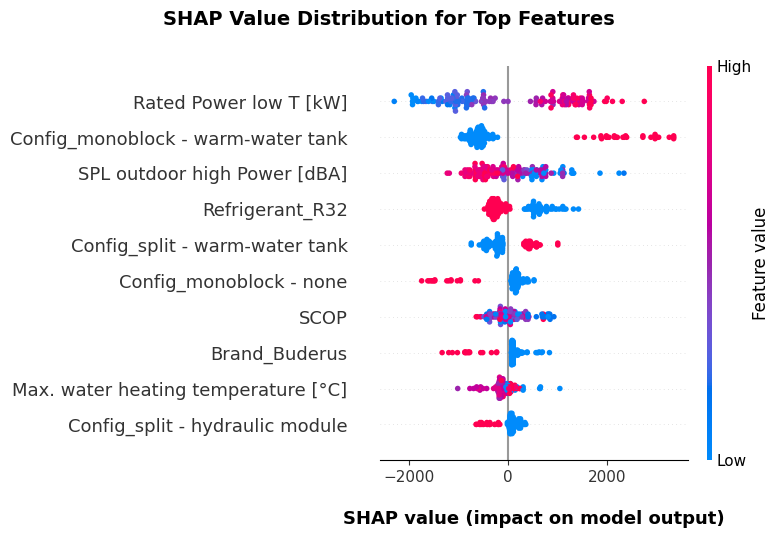

In [5]:
# Perform advanced modeling with gradient boosting and SHAP
advanced_models = lra.perform_advanced_modeling(df)


In [ ]:
# Create regression visualizationsa

# Prepare models dict for visualization function
models_dict = dict(advanced_models)
models_dict['full_model'] = full_model
models_dict['log_model_sm'] = log_model
models_dict['log_model_data'] = {
    'X': X_log_full,
    'y': y_log_full,
    'y_log': y_log_full_data
}

# Try to create visualizations and catch possible ValueError for debugging
try:
    lra.create_regression_visualizations(df, models_dict, figures_dir)
except ValueError as e:
    print("ValueError during visualization:", e)
    import traceback
    traceback.print_exc()
    # Optionally, re-raise if you want execution to stop
    # raise

# Display all visualization files
image_files = [
    'actual_vs_predicted.png',
    'actual_vs_predicted_linear.png',
    'actual_vs_predicted_loglinear.png',
    'residuals_plot.png',
    'residuals_plot_linear.png',
    'residuals_plot_loglinear.png',
    'shap_importance.png',
    'shap_summary.png',
]

for img in image_files:
    path = figures_dir / img
    if path.exists():
        display(Markdown(f"### {img.replace('_', ' ').replace('.png','').title()}"))
        display(Image(filename=str(path)))
    else:
        print(f"Warning: {img} not found")


ValueError during visualization: at least one array or dtype is required


Traceback (most recent call last):
  File "C:\Users\ugnek\AppData\Local\Temp\ipykernel_31444\2391262837.py", line 15, in <module>
    lra.create_regression_visualizations(df, models_dict, figures_dir)
  File "c:\Users\ugnek\OneDrive - ETH Zurich\Desktop\Doktorat\03_Student work\old\Felix Morlock\PricescraperCCDS\PricescraperCCDS\Pricescraper\6_analysis\scripts\linear_regression_analysis.py", line 564, in create_regression_visualizations
    y_pred = models_dict['gb_model'].predict(X)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ugnek\OneDrive - ETH Zurich\Desktop\Doktorat\03_Student work\old\Felix Morlock\PricescraperCCDS\PricescraperCCDS\.venv\Lib\site-packages\sklearn\ensemble\_gb.py", line 2144, in predict
    X = validate_data(
        ^^^^^^^^^^^^^^
  File "c:\Users\ugnek\OneDrive - ETH Zurich\Desktop\Doktorat\03_Student work\old\Felix Morlock\PricescraperCCDS\PricescraperCCDS\.venv\Lib\site-packages\sklearn\utils\validation.py", line 2944, in validate_data
   

In [ ]:
# Model performance summary
print(f"\n{'='*80}")
print("MODEL PERFORMANCE SUMMARY")
print(f"{'='*80}")

# Calculate metrics for linear regression
y_pred_linear = full_model.predict(sm.add_constant(X_full))
linear_rmse = np.sqrt(mean_squared_error(y_full, y_pred_linear))
linear_mae = mean_absolute_error(y_full, y_pred_linear)

print(f"\nLinear Regression:")
print(f"  R²: {full_model.rsquared:.4f}")
print(f"  Adjusted R²: {full_model.rsquared_adj:.4f}")
print(f"  RMSE: {linear_rmse:.2f} EUR")
print(f"  MAE: {linear_mae:.2f} EUR")

# Calculate metrics for log-linear regression (in original scale)
y_pred_log = log_model.predict(sm.add_constant(X_log_full))
y_pred_original = np.exp(y_pred_log) - 1
log_r2_original = r2_score(y_log_full, y_pred_original)
log_rmse = np.sqrt(mean_squared_error(y_log_full, y_pred_original))
log_mae = mean_absolute_error(y_log_full, y_pred_original)

print(f"\nLog-Linear Regression:")
print(f"  R² (log scale): {log_model.rsquared:.4f}")
print(f"  R² (original scale): {log_r2_original:.4f}")
print(f"  Adjusted R²: {log_model.rsquared_adj:.4f}")
print(f"  RMSE: {log_rmse:.2f} EUR")
print(f"  MAE: {log_mae:.2f} EUR")

# Calculate metrics for gradient boosting
if advanced_models and 'gb_model' in advanced_models:
    gb_rmse = np.sqrt(mean_squared_error(y_full, advanced_models['gb_model'].predict(X_full)))
    gb_mae = mean_absolute_error(y_full, advanced_models['gb_model'].predict(X_full))
    
    print(f"\nGradient Boosting:")
    print(f"  R²: {advanced_models.get('gb_r2', 0):.4f}")
    print(f"  RMSE: {gb_rmse:.2f} EUR")
    print(f"  MAE: {gb_mae:.2f} EUR")

print(f"\n{'='*80}")



MODEL PERFORMANCE SUMMARY

Linear Regression:
  R²: 0.8014
  Adjusted R²: 0.7952
  RMSE: 1265.78 EUR
  MAE: 975.31 EUR

Log-Linear Regression:
  R² (log scale): 0.7970
  R² (original scale): 0.7870
  Adjusted R²: 0.7907
  RMSE: 1310.83 EUR
  MAE: 1000.54 EUR

Gradient Boosting:
  R²: 0.8700
  RMSE: 652.05 EUR
  MAE: 415.71 EUR

